# Epidemiological Intelligence — Modelagem Estatística: Leptospirose

## Objetivo

Modela a relação entre variáveis climáticas e o número mensal de casos de **leptospirose** por município, seguindo a metodologia de `02_modeling.ipynb` (módulo `data_science/src/modeling_utils.py`).

Modelos comparados: baseline (média histórica), OLS, Poisson e Binomial Negativa (candidata principal, por sobredispersão esperada em contagens raras/esparsas). Validação sempre **temporal** (treino < 2024-01-01, teste 2024–2025), nunca aleatória. O modelo de referência é `cases ~ C(municipality) + C(month)`, contra o qual são testadas variáveis climáticas e lags de 1 a 3 meses. Como a leptospirose se transmite por contato com água/solo contaminados, a precipitação é a priori a variável mais plausível — mas isso é testado empiricamente, não assumido.

**Nota sobre as enchentes do RS em 2024**: em maio de 2024 o Rio Grande do Sul foi atingido por enchentes severas, associadas a um aumento anômalo de casos de leptospirose (em especial em Porto Alegre). Esses dados **permanecem no teste sem qualquer tratamento especial** — não são removidos nem tratados como outlier, e o modelo **não** é otimizado para detectar esse tipo de evento. O impacto sobre o desempenho é discutido como limitação, não como objetivo alcançado.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm
import statsmodels.formula.api as smf

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import modeling_utils as mu

pd.set_option("display.max_columns", 50)

## 1. Carregamento dos dados

`mu.load_raw_data()` lê `epidemiology_climate_monthly` do cache local em parquet (sem consulta ao BigQuery).

In [2]:
df = mu.load_raw_data()

print("Shape:", df.shape)
print("Colunas:", df.columns.tolist())

Shape: (21384, 19)
Colunas: ['municipality', 'year', 'month', 'municipality_code', 'reference_date', 'cases', 'source_file', 'ingestion_timestamp', 'disease', 'precipitation_sum_mm', 'precipitation_avg_observation_mm', 'precipitation_max_observation_mm', 'temperature_avg_c', 'dew_point_avg_c', 'relative_humidity_avg_pct', 'atmospheric_pressure_avg_mb', 'wind_speed_avg_ms', 'wind_gust_max_ms', 'station_count']


In [3]:
print("Tipo de reference_date:", df["reference_date"].dtype)
df[["reference_date", "municipality", "disease", "cases"]].head()

Tipo de reference_date: datetime64[ms]


,reference_date,municipality,disease,cases
0,2015-01-01,BAGE,ASMA,4
1,2015-01-01,BAGE,BRONQUITE AGUDA,0
2,2015-01-01,BAGE,BRONQUITE CRÔNICA,7
3,2015-01-01,BAGE,INFARTO AGUDO DO MIOCÁRDIO,11
4,2015-01-01,BAGE,INSUFICIÊNCIA CARDÍACA,18


## 2. Lags climáticos

Os lags são construídos em uma tabela auxiliar de uma linha por município/mês (`mu.build_climate_monthly_lags`), evitando misturar valores entre doenças. A função valida ausência de duplicatas e a continuidade mensal antes de gerar lags de 1 a 3 meses (usa cache já existente). Em seguida são mesclados de volta via `mu.merge_climate_lags`, validando que o merge não cria duplicatas disease/municipality/reference_date.

In [4]:
climate_monthly = mu.build_climate_monthly_lags(df)

print("Shape climate_monthly:", climate_monthly.shape)

lag_cols_preview = [c for c in climate_monthly.columns if "_lag" in c]
print("Número de colunas de lag geradas:", len(lag_cols_preview))

check_climate = (
    climate_monthly[climate_monthly["municipality"] == "PORTO ALEGRE"]
    [["reference_date", "precipitation_sum_mm", "precipitation_sum_mm_lag1",
      "precipitation_sum_mm_lag2", "precipitation_sum_mm_lag3"]]
    .sort_values("reference_date")
)
display(check_climate.head(12))

Shape climate_monthly: (3564, 38)
Número de colunas de lag geradas: 27


,reference_date,precipitation_sum_mm,precipitation_sum_mm_lag1,precipitation_sum_mm_lag2,precipitation_sum_mm_lag3
1716,2015-01-01,159.8,NaN,NaN,NaN
1717,2015-02-01,99.4,159.8,NaN,NaN
1718,2015-03-01,54.0,99.4,159.8,NaN
1719,2015-04-01,76.0,54.0,99.4,159.8
1720,2015-05-01,142.4,76.0,54.0,99.4
1721,2015-06-01,172.4,142.4,76.0,54.0
1722,2015-07-01,313.4,172.4,142.4,76.0
1723,2015-08-01,111.6,313.4,172.4,142.4
1724,2015-09-01,186.6,111.6,313.4,172.4
1725,2015-10-01,312.6,186.6,111.6,313.4


In [5]:
df = mu.merge_climate_lags(df, climate_monthly)

print("Shape df após merge dos lags:", df.shape)

check_lags = (
    df[(df["municipality"] == "PORTO ALEGRE") & (df["disease"] == "LEPTOSPIROSE")]
    [["reference_date", "cases", "precipitation_sum_mm", "precipitation_sum_mm_lag1",
      "precipitation_sum_mm_lag2", "precipitation_sum_mm_lag3",
      "relative_humidity_avg_pct", "relative_humidity_avg_pct_lag1"]]
    .sort_values("reference_date")
)
display(check_lags.head(12))

Shape df após merge dos lags: (21384, 46)


,reference_date,cases,precipitation_sum_mm,precipitation_sum_mm_lag1,precipitation_sum_mm_lag2,precipitation_sum_mm_lag3,relative_humidity_avg_pct,relative_humidity_avg_pct_lag1
83,2015-01-01,5,159.8,NaN,NaN,NaN,75.452957,NaN
245,2015-02-01,3,99.4,159.8,NaN,NaN,77.730655,75.452957
407,2015-03-01,9,54.0,99.4,159.8,NaN,75.274194,77.730655
569,2015-04-01,3,76.0,54.0,99.4,159.8,76.897222,75.274194
731,2015-05-01,9,142.4,76.0,54.0,99.4,81.487903,76.897222
893,2015-06-01,4,172.4,142.4,76.0,54.0,82.341326,81.487903
1055,2015-07-01,3,313.4,172.4,142.4,76.0,87.428763,82.341326
1217,2015-08-01,7,111.6,313.4,172.4,142.4,74.266129,87.428763
1379,2015-09-01,3,186.6,111.6,313.4,172.4,79.538354,74.266129
1541,2015-10-01,10,312.6,186.6,111.6,313.4,82.672043,79.538354


## 3. Split temporal

Divisão fixa treino/teste em 2024-01-01 (nunca aleatória). O teste (2024–2025) inclui, sem filtro especial, o período das enchentes do RS de 2024.

In [6]:
train_df, test_df = mu.temporal_split(df)

print("Treino:", train_df["reference_date"].min(), "→", train_df["reference_date"].max())
print("Teste:", test_df["reference_date"].min(), "→", test_df["reference_date"].max())
print("Treino shape:", train_df.shape)
print("Teste shape:", test_df.shape)

Treino: 2015-01-01 00:00:00 → 2023-12-01 00:00:00
Teste: 2024-01-01 00:00:00 → 2025-12-01 00:00:00
Treino shape: (17496, 46)
Teste shape: (3888, 46)


## 4. Filtragem da doença: Leptospirose

`mu.prepare_disease_frame` filtra a doença, remove (nunca preenche com zero) linhas com valores ausentes nas colunas exigidas e ajusta tipos para `patsy`/`statsmodels`.

In [7]:
DISEASE = mu.DISEASES["leptospirose"]
print("Doença:", DISEASE)

train_disease0 = mu.prepare_disease_frame(train_df, DISEASE)
test_disease0 = mu.prepare_disease_frame(test_df, DISEASE)

print("Treino (doença):", train_disease0.shape)
print("Teste (doença):", test_disease0.shape)

print("\nDistribuição anual de casos (para contextualizar o pico de 2024):")
year_counts = df[df["disease"] == DISEASE].copy()
year_counts["year"] = year_counts["reference_date"].dt.year
display(year_counts.groupby("year")["cases"].sum())

Doença: LEPTOSPIROSE
Treino (doença): (1704, 46)
Teste (doença): (504, 46)

Distribuição anual de casos (para contextualizar o pico de 2024):


year
2015    161
2016    128
2017    162
2018    119
2019    183
2020     57
2021     56
2022    101
2023    146
2024    484
2025     94
Name: cases, dtype: Int64

## 5. Baselines simples (comparação metodológica)

Reprodução compacta da comparação já feita em `02_modeling.ipynb` (baseline, OLS, Poisson, NB simples) para justificar a NB a partir da sobredispersão observada. Leptospirose é rara e esparsa (muitos municípios com zero casos), então as métricas absolutas aqui são pequenas — o objetivo é comparar a forma funcional dos modelos, não a qualidade final do ajuste.

In [8]:
baseline_pred_value = train_disease0["cases"].mean()
test_baseline = test_disease0.copy()
test_baseline["baseline_pred"] = baseline_pred_value

baseline_metrics = mu.regression_metrics(test_baseline["cases"], test_baseline["baseline_pred"])
print("Média histórica (treino):", round(baseline_pred_value, 4))
print("Baseline (média histórica) — MAE:", round(baseline_metrics["mae"], 4), "RMSE:", round(baseline_metrics["rmse"], 4))

Média histórica (treino): 0.6532
Baseline (média histórica) — MAE: 1.4112 RMSE: 7.6987


In [9]:
ols_simple = smf.ols(formula="cases ~ temperature_avg_c", data=train_disease0).fit()
print(ols_simple.summary())

                            OLS Regression Results                            
Dep. Variable:                  cases   R-squared:                       0.028
Model:                            OLS   Adj. R-squared:                  0.028
Method:                 Least Squares   F-statistic:                     48.47
Date:                Wed, 26 Aug 2026   Prob (F-statistic):           4.80e-12
Time:                        19:18:12   Log-Likelihood:                -3119.8
No. Observations:                1673   AIC:                             6244.
Df Residuals:                    1671   BIC:                             6255.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            -0.6239      0.18

In [10]:
test_ols = test_disease0.copy()
test_ols["ols_pred"] = ols_simple.predict(test_ols)

ols_eval = test_ols[test_ols["cases"].notna() & test_ols["ols_pred"].notna()].copy()
ols_metrics = mu.regression_metrics(ols_eval["cases"], ols_eval["ols_pred"])

print("Linhas no teste:", len(test_ols), " | Linhas avaliadas (sem NaN de temperatura):", len(ols_eval))
print("OLS simples — MAE:", round(ols_metrics["mae"], 4), "RMSE:", round(ols_metrics["rmse"], 4))
print("Previsões negativas:", int((ols_eval["ols_pred"] < 0).sum()))

Linhas no teste: 504  | Linhas avaliadas (sem NaN de temperatura): 448
OLS simples — MAE: 1.5032 RMSE: 8.1763
Previsões negativas: 0


In [11]:
poisson_simple = smf.glm(
    formula="cases ~ temperature_avg_c",
    data=train_disease0,
    family=sm.families.Poisson(),
).fit()

test_poisson = test_disease0.copy()
test_poisson["poisson_pred"] = poisson_simple.predict(test_poisson)
poisson_eval = test_poisson[test_poisson["cases"].notna() & test_poisson["poisson_pred"].notna()].copy()
poisson_metrics = mu.regression_metrics(poisson_eval["cases"], poisson_eval["poisson_pred"])

dispersion = poisson_simple.pearson_chi2 / poisson_simple.df_resid

print("Poisson simples — MAE:", round(poisson_metrics["mae"], 4), "RMSE:", round(poisson_metrics["rmse"], 4))
print("Dispersão (Pearson chi2 / df_resid):", round(dispersion, 4))

Poisson simples — MAE: 1.51 RMSE: 8.1776
Dispersão (Pearson chi2 / df_resid): 3.5528


A razão entre o qui-quadrado de Pearson e os graus de liberdade é ≈3,5 (bem acima de 1), indicando sobredispersão — a variância excede a média mesmo em um modelo simples com apenas temperatura. Isso viola a equidispersão da Poisson e justifica a Binomial Negativa, que acomoda o excesso de variância via o parâmetro `alpha`.

In [12]:
nb_simple = mu.fit_negbin("cases ~ temperature_avg_c", train_disease0)

test_nb_simple = test_disease0.copy()
test_nb_simple["nb_pred"] = nb_simple.predict(test_nb_simple)
nb_simple_eval = test_nb_simple[test_nb_simple["cases"].notna() & test_nb_simple["nb_pred"].notna()].copy()
nb_simple_metrics = mu.regression_metrics(nb_simple_eval["cases"], nb_simple_eval["nb_pred"])

print("Binomial Negativa simples — MAE:", round(nb_simple_metrics["mae"], 4), "RMSE:", round(nb_simple_metrics["rmse"], 4))
print("Alpha:", round(nb_simple.params["alpha"], 4))
print("Convergiu:", nb_simple.mle_retvals.get("converged", False))

Binomial Negativa simples — MAE: 1.5115 RMSE: 8.1781
Alpha: 2.7924
Convergiu: True


O modelo univariado com apenas temperatura (OLS, Poisson ou NB) tem desempenho muito próximo entre si e do baseline — temperatura isolada não separa bem os casos. Esperado: leptospirose depende fortemente de efeitos estruturais por município (saneamento, corpos d'água, histórico de enchentes) e de sazonalidade, ainda não controlados nesta comparação simples.

## 6. Modelo de referência da doença: Binomial Negativa (município + mês)

Modelo de referência contra o qual toda contribuição climática é avaliada: `cases ~ C(municipality) + C(month)`, sem variável climática. `SOLEDADE` aparece no teste mas não no treino da doença (sem casos antes de 2024); como o modelo usa `C(municipality)`, não pode prever para uma categoria não vista — essas linhas são excluídas da avaliação, nunca inventadas.

In [13]:
base_model_ref = mu.fit_negbin(mu.BASE_FORMULA, train_disease0)

test_base_ref, unseen_base = mu.drop_unseen_municipalities(train_disease0, test_disease0)
print("Municípios excluídos por não terem sido vistos no treino:", unseen_base)

test_base_ref = test_base_ref.copy()
test_base_ref["base_pred"] = base_model_ref.predict(test_base_ref)

base_ref_metrics = mu.regression_metrics(test_base_ref["cases"], test_base_ref["base_pred"])

print("Convergiu:", base_model_ref.mle_retvals.get("converged", False))
print("Alpha:", round(base_model_ref.params["alpha"], 4))
print("MAE:", round(base_ref_metrics["mae"], 4))
print("RMSE:", round(base_ref_metrics["rmse"], 4))

Municípios excluídos por não terem sido vistos no treino:

 {'SOLEDADE'}
Convergiu: True
Alpha: 0.3183
MAE: 1.1131
RMSE: 7.5052


### Nota: validação dedicada (2023) para seleção de features

Os testes de variáveis climáticas e de lag (seções 7–8) usam um split de validação dedicado (`mu.feature_selection_split`: treino-para-seleção 2015–2022, validação 2023) em vez do conjunto de teste 2024–2025, evitando o viés do "vencedor" (escolher entre várias candidatas usando o mesmo conjunto depois usado para reportar performance). O modelo final (seção 10+) continua treinado em 2015–2023 e avaliado em 2024–2025, sem mudança. Como a validação usada mudou, os ganhos percentuais e a ordem de relevância das variáveis diferem da primeira versão do notebook — mas as duas features finais selecionadas permanecem as mesmas.

In [14]:
train_fs_df, validation_fs_df = mu.feature_selection_split(train_df)

train_disease_fs = mu.prepare_disease_frame(train_fs_df, DISEASE)
validation_disease_fs = mu.prepare_disease_frame(validation_fs_df, DISEASE)

print("Treino-para-seleção:", train_fs_df["reference_date"].min(), "→", train_fs_df["reference_date"].max())
print("Validação:          ", validation_fs_df["reference_date"].min(), "→", validation_fs_df["reference_date"].max())
print("Treino-para-seleção (doença):", train_disease_fs.shape)
print("Validação (doença):          ", validation_disease_fs.shape)

Treino-para-seleção: 2015-01-01 00:00:00 → 2022-12-01 00:00:00
Validação:           2023-01-01 00:00:00 → 2023-12-01 00:00:00
Treino-para-seleção (doença): (1512, 46)
Validação (doença):           (192, 46)


## 7. Contribuição individual das variáveis climáticas

Cada uma das 9 variáveis (`mu.CLIMATE_VARS`) é testada individualmente, somada ao modelo-base. Base e modelo climático são ajustados nas mesmas linhas de treino/teste; municípios não vistos no treino são excluídos da avaliação.

In [15]:
print("Variáveis climáticas testadas:", mu.CLIMATE_VARS)

climate_comparison = mu.evaluate_candidate_features(
    train_disease_fs, validation_disease_fs, mu.CLIMATE_VARS
)

display(climate_comparison.round(4))

Variáveis climáticas testadas: ['temperature_avg_c', 'dew_point_avg_c', 'relative_humidity_avg_pct', 'atmospheric_pressure_avg_mb', 'wind_speed_avg_ms', 'wind_gust_max_ms', 'precipitation_sum_mm', 'precipitation_avg_observation_mm', 'precipitation_max_observation_mm']


C:\Users\eduar\Desktop\Projeto-Python\epidemiological-intelligence\.venv\Lib\site-packages\statsmodels\discrete\discrete_model.py:3379: RuntimeWarning: divide by zero encountered in log
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)
C:\Users\eduar\Desktop\Projeto-Python\epidemiological-intelligence\.venv\Lib\site-packages\statsmodels\discrete\discrete_model.py:3379: RuntimeWarning: invalid value encountered in multiply
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)


C:\Users\eduar\Desktop\Projeto-Python\epidemiological-intelligence\.venv\Lib\site-packages\statsmodels\discrete\discrete_model.py:3379: RuntimeWarning: divide by zero encountered in log
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)
C:\Users\eduar\Desktop\Projeto-Python\epidemiological-intelligence\.venv\Lib\site-packages\statsmodels\discrete\discrete_model.py:3379: RuntimeWarning: invalid value encountered in multiply
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)


,variable,train_n,test_n,coef,pvalue,alpha,base_mae,mae,mae_improvement_pct,base_rmse,rmse,rmse_improvement_pct,base_converged,converged
0,relative_humidity_avg_pct,1462,168,0.0373,0.0000,0.2286,0.7752,0.7381,4.7883,1.6030,1.5051,6.1024,True,True
1,precipitation_sum_mm,1438,170,0.0015,0.0035,0.2476,0.7786,0.7598,2.4190,1.5959,1.5553,2.5446,True,True
2,precipitation_avg_observation_mm,1438,170,0.7976,0.0258,0.2573,0.7786,0.7642,1.8515,1.5959,1.5662,1.8575,True,True
3,wind_gust_max_ms,1472,165,-0.0230,0.0374,0.2874,0.7868,0.7737,1.6706,1.6242,1.6040,1.2458,True,True
4,wind_speed_avg_ms,1473,165,-0.4138,0.0002,0.2627,0.7869,0.7763,1.3419,1.6243,1.6475,-1.4294,True,True
5,dew_point_avg_c,1461,168,0.1483,0.0000,0.2107,0.7750,0.7793,-0.5495,1.6028,1.5693,2.0856,True,True
6,atmospheric_pressure_avg_mb,1492,170,-0.0718,0.0300,0.2791,0.7745,0.7796,-0.6544,1.6008,1.6408,-2.4950,True,True
7,temperature_avg_c,1491,170,0.0767,0.0153,0.2683,0.7743,0.7943,-2.5746,1.6006,1.6268,-1.6339,True,True
8,precipitation_max_observation_mm,1438,170,0.0100,0.0170,0.2525,0.7786,0.8152,-4.6967,1.5959,1.7163,-7.5442,True,True


## 8. Seleção das variáveis relevantes para teste de defasagem (lag)

Com a validação de 2023, a variável com melhor combinação de ganho preditivo e significância é **relative_humidity_avg_pct** (MAE ≈4,79%, RMSE ≈6,10%, p<0,0001); na primeira versão (validada em 2024–2025) a precipitação aparecia na frente — a ordem mudou, mas ambas seguem relevantes. `precipitation_sum_mm` (MAE ≈2,42%, p≈0,0035) e `precipitation_avg_observation_mm` (MAE ≈1,85%, p≈0,0258) também têm ganho. `precipitation_max_observation_mm` teve desempenho negativo apesar de p≈0,0170 significativo — mantida no teste de lags por plausibilidade mecanística (chuva extrema pode ter efeito defasado). Rajada/vento tiveram p significativo mas ganho pequeno e foram deixados de fora por menor plausibilidade epidemiológica; temperatura, ponto de orvalho e pressão tiveram ganho nulo/negativo e não seguem adiante.

Quatro variáveis seguem para o teste de defasagens (atual, lag1–3), usando as colunas de lag já mescladas:

In [16]:
lag_variables = [
    "precipitation_sum_mm",
    "precipitation_avg_observation_mm",
    "precipitation_max_observation_mm",
    "relative_humidity_avg_pct",
]

lag_candidates = mu.lag_candidates(lag_variables)
print("Número de variáveis testadas (atual + lag1..3):", len(lag_candidates))
print(lag_candidates)

Número de variáveis testadas (atual + lag1..3): 16
['precipitation_sum_mm', 'precipitation_sum_mm_lag1', 'precipitation_sum_mm_lag2', 'precipitation_sum_mm_lag3', 'precipitation_avg_observation_mm', 'precipitation_avg_observation_mm_lag1', 'precipitation_avg_observation_mm_lag2', 'precipitation_avg_observation_mm_lag3', 'precipitation_max_observation_mm', 'precipitation_max_observation_mm_lag1', 'precipitation_max_observation_mm_lag2', 'precipitation_max_observation_mm_lag3', 'relative_humidity_avg_pct', 'relative_humidity_avg_pct_lag1', 'relative_humidity_avg_pct_lag2', 'relative_humidity_avg_pct_lag3']


In [17]:
lag_comparison = mu.evaluate_candidate_features(
    train_disease_fs, validation_disease_fs, lag_candidates
)

display(
    lag_comparison[
        ["variable", "train_n", "test_n", "coef", "pvalue",
         "mae_improvement_pct", "rmse_improvement_pct", "alpha",
         "base_converged", "converged"]
    ].round(4)
)

C:\Users\eduar\Desktop\Projeto-Python\epidemiological-intelligence\.venv\Lib\site-packages\statsmodels\discrete\discrete_model.py:3379: RuntimeWarning: divide by zero encountered in log
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)
C:\Users\eduar\Desktop\Projeto-Python\epidemiological-intelligence\.venv\Lib\site-packages\statsmodels\discrete\discrete_model.py:3379: RuntimeWarning: invalid value encountered in multiply
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)
C:\Users\eduar\Desktop\Projeto-Python\epidemiological-intelligence\.venv\Lib\site-packages\statsmodels\discrete\discrete_model.py:3379: RuntimeWarning: divide by zero encountered in log
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)
C:\Users\eduar\Desktop\Projeto-Python\epidemiological-intelligence\.venv\Lib\site-packages\statsmodels\discrete\discrete_model.py:3379: RuntimeWarning: invalid value encountered in multiply
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)


C:\Users\eduar\Desktop\Projeto-Python\epidemiological-intelligence\.venv\Lib\site-packages\statsmodels\discrete\discrete_model.py:3379: RuntimeWarning: divide by zero encountered in log
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)
C:\Users\eduar\Desktop\Projeto-Python\epidemiological-intelligence\.venv\Lib\site-packages\statsmodels\discrete\discrete_model.py:3379: RuntimeWarning: invalid value encountered in multiply
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)
C:\Users\eduar\Desktop\Projeto-Python\epidemiological-intelligence\.venv\Lib\site-packages\statsmodels\discrete\discrete_model.py:3379: RuntimeWarning: divide by zero encountered in log
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)
C:\Users\eduar\Desktop\Projeto-Python\epidemiological-intelligence\.venv\Lib\site-packages\statsmodels\discrete\discrete_model.py:3379: RuntimeWarning: invalid value encountered in multiply
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)
C:\Users\eduar\Deskt

,variable,train_n,test_n,coef,pvalue,mae_improvement_pct,rmse_improvement_pct,alpha,base_converged,converged
0,relative_humidity_avg_pct_lag1,1445,166,0.0511,0.0000,5.9522,7.6941,0.2298,True,True
1,precipitation_sum_mm_lag3,1386,170,0.0009,NaN,5.5431,6.1567,1.0513,True,False
2,relative_humidity_avg_pct,1462,168,0.0373,0.0000,4.7883,6.1024,0.2286,True,True
3,precipitation_sum_mm_lag1,1421,169,0.0021,0.0000,4.6066,10.4968,0.2573,True,True
4,precipitation_avg_observation_mm_lag1,1421,169,1.3926,0.0000,3.8627,9.2527,0.2623,True,True
5,relative_humidity_avg_pct_lag2,1428,166,0.0323,0.0003,3.2983,2.5333,0.2748,True,True
6,precipitation_sum_mm_lag2,1405,170,0.0019,0.0003,3.0986,1.6479,0.2623,True,True
7,precipitation_avg_observation_mm_lag3,1386,170,0.5376,0.1350,2.6846,3.3765,0.2862,True,True
8,precipitation_avg_observation_mm_lag2,1405,170,1.1832,0.0009,2.6326,1.4899,0.2656,True,True
9,precipitation_sum_mm,1438,170,0.0015,0.0035,2.4190,2.5446,0.2476,True,True


## 9. Seleção final de features

A escolha considera conjuntamente desempenho fora da amostra (validação 2023), p-value, coerência epidemiológica, convergência e risco de multicolinearidade — nunca apenas a melhor métrica isolada ou o menor p-value.

**relative_humidity_avg_pct_lag1** tem o melhor resultado individual (MAE ≈5,95%, RMSE ≈7,69%, p<0,0001, converge). `precipitation_sum_mm_lag3` aparenta ganho maior mas **não convergiu** (`converged=False`) e é descartada por esse motivo, independente do ganho nominal. `relative_humidity_avg_pct` (contemporânea) e **precipitation_sum_mm_lag1** (MAE ≈4,61%, RMSE ≈10,50%, p<0,0001, converge) são as próximas melhores opções confiáveis. `precipitation_avg_observation_mm_lag1` tem desempenho parecido com `precipitation_sum_mm_lag1`, mas correlação ≈0,97 com ela (mesmo fenômeno) — apenas a de melhor desempenho isolado é mantida.

Features finais (as mesmas da primeira versão do notebook): **precipitation_sum_mm_lag1** (melhor RMSE isolado entre lags que convergem; um mês é compatível com incubação + exposição pós-chuva + atraso de notificação) e **relative_humidity_avg_pct_lag1** (melhor MAE isolado; coerente com sobrevivência da bactéria *Leptospira* em ambiente úmido). Correlação moderada entre as duas (≈0,33); ajustadas em conjunto, o ganho combinado (MAE ≈7,13%, RMSE ≈11,23%) supera o de qualquer uma isolada — evidência de contribuição complementar, não apenas redundante.

```
precipitation_sum_mm_lag1
relative_humidity_avg_pct_lag1
```

A lista não mudou em relação à primeira versão do notebook, mas agora é sustentada por uma validação (2023) nunca usada para reportar a performance final, eliminando o viés do "vencedor".

In [18]:
features_selecionadas = [
    "precipitation_sum_mm_lag1",
    "relative_humidity_avg_pct_lag1",
]

feature_selection_rationale = (
    "Selecionadas com base na validacao dedicada de 2023 (mu.feature_selection_split), "
    "nunca no conjunto de teste 2024-2025: precipitation_sum_mm_lag1 (melhor ganho de "
    "RMSE isolado entre as defasagens que convergem de forma confiavel, ~10.5%, "
    "p<0.0001) e relative_humidity_avg_pct_lag1 (melhor ganho de MAE isolado, ~5.95%, "
    "p<0.0001). Correlacao moderada entre as duas (~0.33), sem multicolinearidade "
    "relevante; ganho combinado na validacao (MAE ~7.13%, RMSE ~11.23%) supera o de "
    "qualquer uma isoladamente. precipitation_avg_observation_mm_lag1 foi descartada "
    "por alta colinearidade (~0.97) com precipitation_sum_mm_lag1; "
    "precipitation_sum_mm_lag3 foi descartada por nao convergir apesar do ganho "
    "aparente; precipitation_max_observation_mm e as variaveis de vento tiveram "
    "desempenho fraco ou inconsistente e nao epidemiologicamente centrais. Estas sao "
    "as mesmas duas features selecionadas antes da correcao do vazamento de "
    "validacao; a correcao mudou a validacao usada para escolhe-las, nao a escolha "
    "final."
)

print(features_selecionadas)

['precipitation_sum_mm_lag1', 'relative_humidity_avg_pct_lag1']


## 10. Modelo multivariado final

Ajuste do modelo-base e do modelo final nas mesmas linhas (via `mu.fit_final_models`); `alpha` é estimado pelo próprio `smf.negativebinomial` (nunca fixado em 1). Por leptospirose ser mais rara/esparsa, a convergência é verificada explicitamente; se não convergir com `maxiter=500`, reajusta com `maxiter=1000`.

In [19]:
resultado = mu.fit_final_models(train_disease0, test_disease0, features_selecionadas)

if not resultado["final_converged"]:
    print("Modelo final não convergiu com maxiter=500; reajustando com maxiter=1000...")
    resultado = mu.fit_final_models(
        train_disease0, test_disease0, features_selecionadas, maxiter=1000
    )

final_model = resultado["final_model"]
base_model = resultado["base_model"]

print(final_model.summary())

                     NegativeBinomial Regression Results                      
Dep. Variable:                  cases   No. Observations:                 1570
Model:               NegativeBinomial   Df Residuals:                     1532
Method:                           MLE   Df Model:                           37
Date:                Wed, 26 Aug 2026   Pseudo R-squ.:                  0.2407
Time:                        19:18:16   Log-Likelihood:                -1273.4
converged:                       True   LL-Null:                       -1677.1
Covariance Type:            nonrobust   LLR p-value:                1.290e-145
                                              coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------
Intercept                                  -3.9522      0.746     -5.299      0.000      -5.414      -2.490
C(municipality)[T.CACAPAVA DO SUL]         -

C:\Users\eduar\Desktop\Projeto-Python\epidemiological-intelligence\.venv\Lib\site-packages\statsmodels\discrete\discrete_model.py:3379: RuntimeWarning: divide by zero encountered in log
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)
C:\Users\eduar\Desktop\Projeto-Python\epidemiological-intelligence\.venv\Lib\site-packages\statsmodels\discrete\discrete_model.py:3379: RuntimeWarning: invalid value encountered in multiply
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)


In [20]:
print("Convergiu (base):", resultado["base_converged"])
print("Convergiu (final):", resultado["final_converged"])
print("Alpha estimado:", round(resultado["alpha"], 4))
print("AIC:", round(final_model.aic, 2))
print("Log-Likelihood:", round(final_model.llf, 2))

print("\nCoeficientes das features climáticas:")
for feature in features_selecionadas:
    print(f"  {feature}: coef={final_model.params[feature]:.6f}  p-value={final_model.pvalues[feature]:.4f}")

Convergiu (base): True
Convergiu (final): True
Alpha estimado: 0.2318
AIC: 2624.79
Log-Likelihood: -1273.4

Coeficientes das features climáticas:
  precipitation_sum_mm_lag1: coef=0.001193  p-value=0.0164
  relative_humidity_avg_pct_lag1: coef=0.041587  p-value=0.0001


In [21]:
base_metrics = resultado["base_metrics"]
final_metrics = resultado["final_metrics"]

print("MODELO-BASE (município + mês)")
print("  MAE:", round(base_metrics["mae"], 4))
print("  RMSE:", round(base_metrics["rmse"], 4))

print("\nMODELO FINAL (clima)")
print("  MAE:", round(final_metrics["mae"], 4))
print("  RMSE:", round(final_metrics["rmse"], 4))
print("  R²:", round(final_metrics["r2"], 4))
print("  WAPE (%):", round(final_metrics["wape_pct"], 2))

print("\nMelhora MAE (%):", round(resultado["mae_improvement_pct"], 2))
print("Melhora RMSE (%):", round(resultado["rmse_improvement_pct"], 2))

print("\nLinhas treino:", len(resultado["train_final"]), " | Linhas teste:", len(resultado["test_final"]))

MODELO-BASE (município + mês)
  MAE: 1.2164
  RMSE: 7.9869

MODELO FINAL (clima)
  MAE: 1.1838
  RMSE: 7.8231
  R²: 0.1046
  WAPE (%): 91.09

Melhora MAE (%): 2.68
Melhora RMSE (%): 2.05

Linhas treino: 1570  | Linhas teste: 434


## 11. Backtest e gráficos

### A) Real vs previsto — todos os municípios (2024–2025)

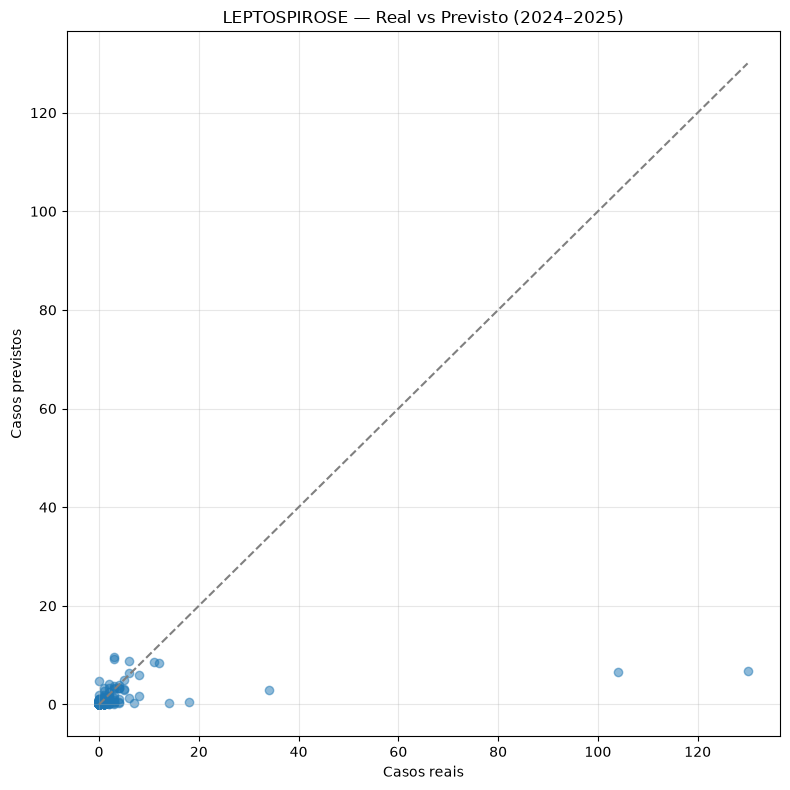

In [22]:
mu.plot_real_vs_predicted(resultado["test_final"]["cases"], resultado["final_pred"], DISEASE)

### B) Backtest temporal por município

Porto Alegre é, de longe, o município com mais casos — inclusive concentrando o pico anômalo de maio/junho de 2024 das enchentes do RS — e é usado como referência principal. São incluídos também os dois municípios seguintes em volume de casos no teste.

Porto Alegre presente nos dados da doença: True


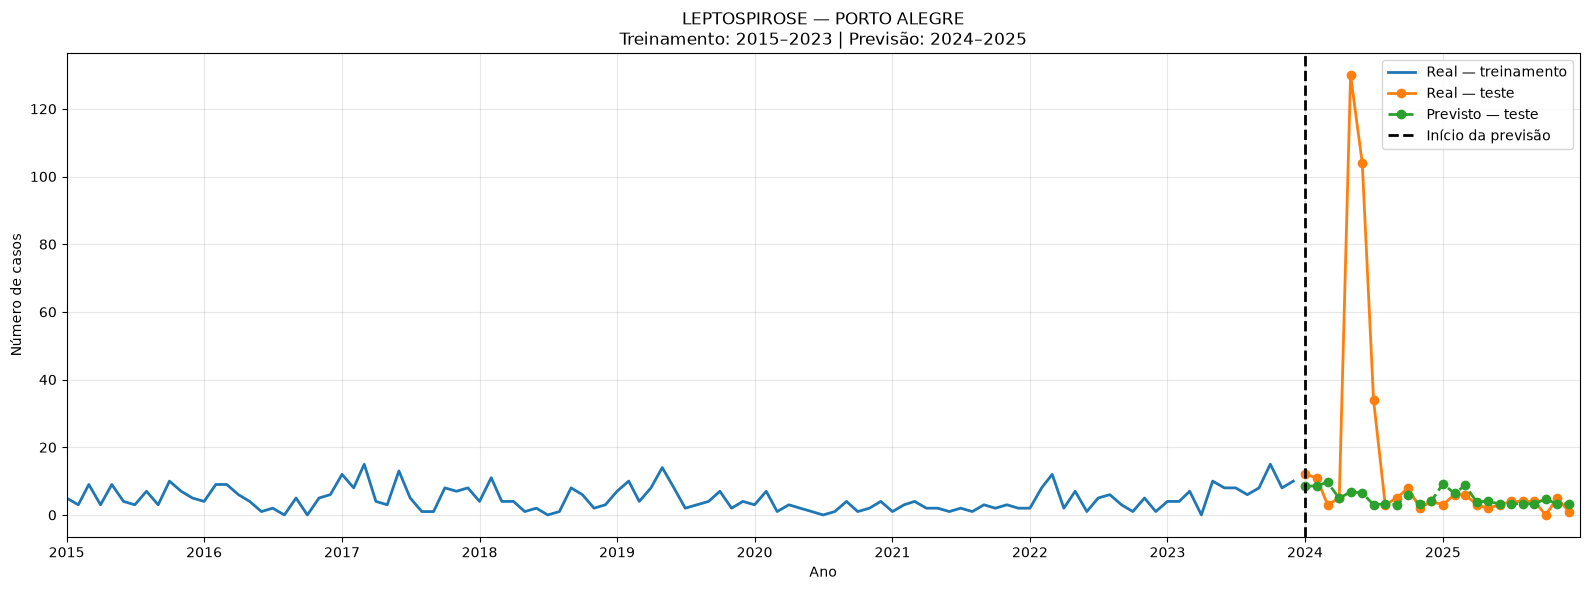

In [23]:
historical_df = train_disease0.copy()

forecast_df = resultado["test_final"].copy()
forecast_df["prediction"] = resultado["final_pred"]

plot_backtest = mu.make_backtest_plotter(DISEASE, historical_df, forecast_df)

print("Porto Alegre presente nos dados da doença:", "PORTO ALEGRE" in forecast_df["municipality"].unique())

plot_backtest("PORTO ALEGRE")

municipality
PORTO ALEGRE    362.0
RIO GRANDE       44.0
SANTA MARIA      39.0
PASSO FUNDO      21.0
ERECHIM          15.0
SAO BORJA        13.0
Name: cases, dtype: float64

Municípios adicionais escolhidos (maior volume de casos após Porto Alegre): RIO GRANDE e SANTA MARIA


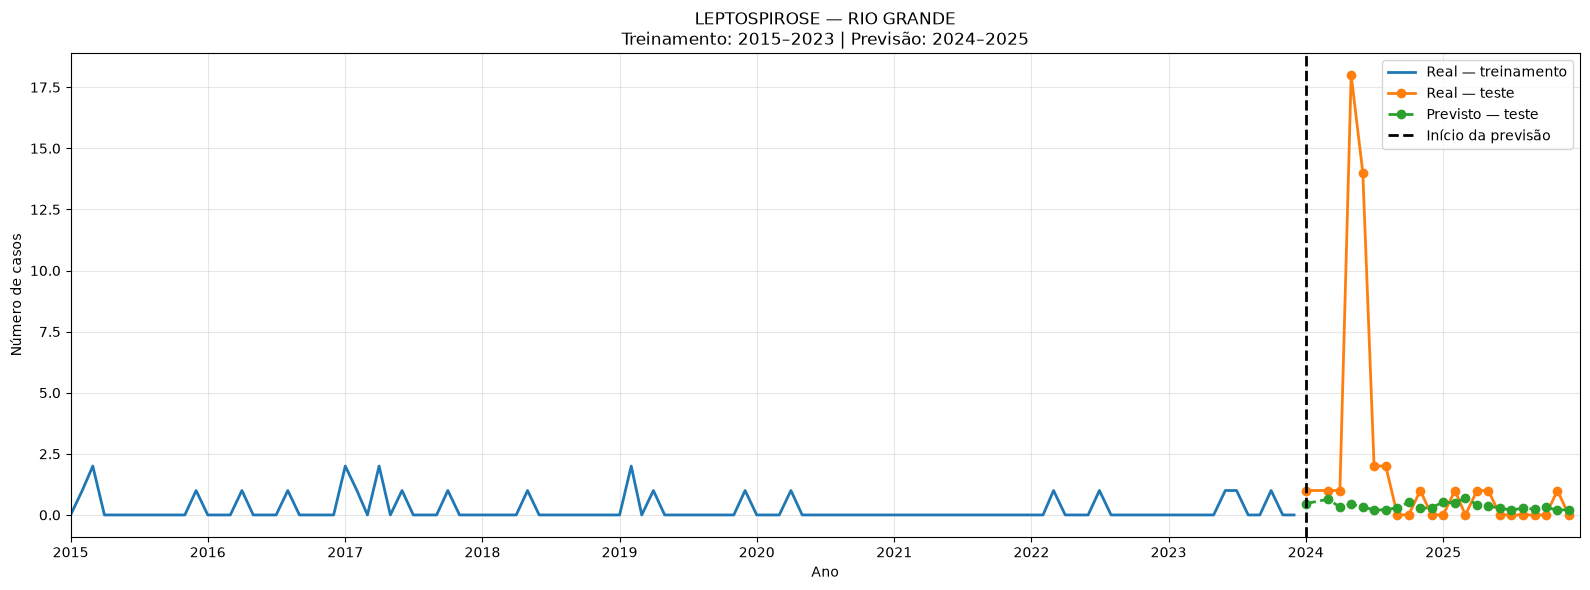

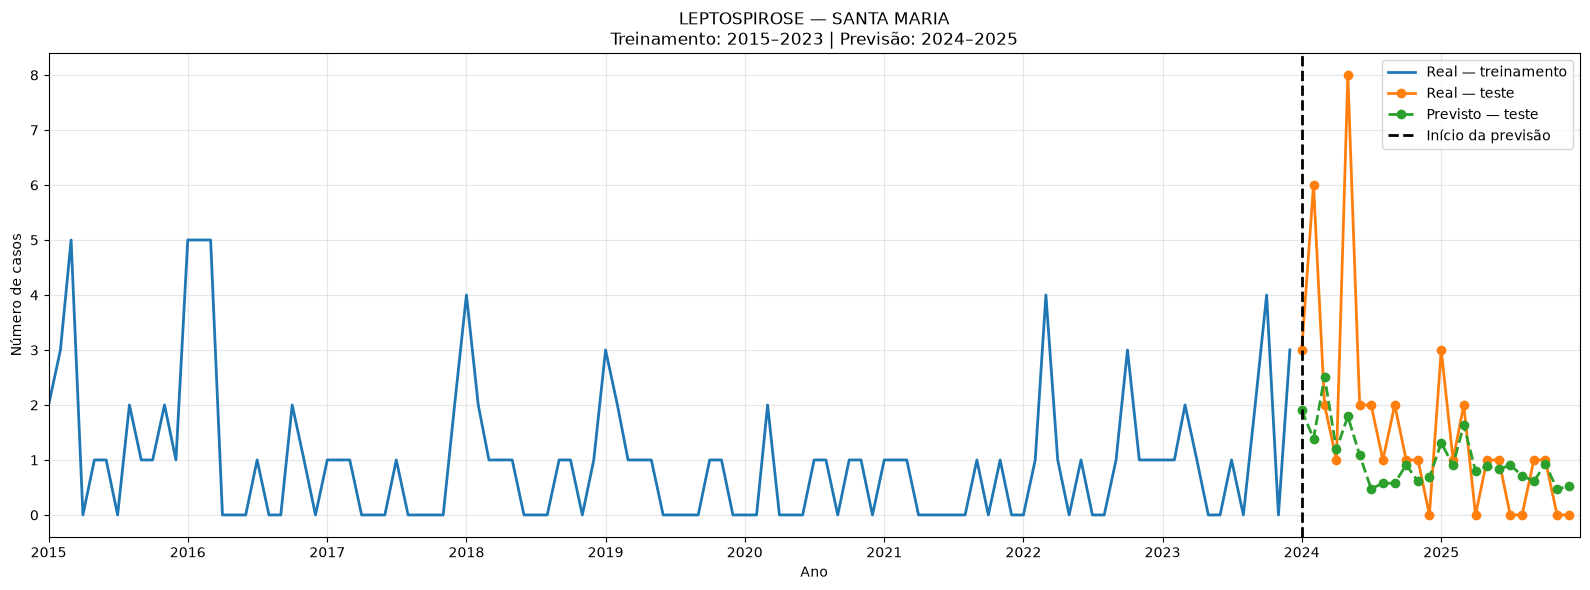

In [24]:
top_municipalities = (
    forecast_df.groupby("municipality")["cases"].sum().sort_values(ascending=False)
)
print(top_municipalities.head(6))

remaining = [m for m in top_municipalities.index if m != "PORTO ALEGRE"]
second_city = remaining[0]
third_city = remaining[1]

print("\nMunicípios adicionais escolhidos (maior volume de casos após Porto Alegre):", second_city, "e", third_city)

plot_backtest(second_city)
plot_backtest(third_city)

### C) Baseline (município + mês) vs modelo climático vs real — Porto Alegre (2024–2025)

O pico de maio/junho de 2024 (enchentes do RS) é visível no gráfico abaixo, mantido sem qualquer ajuste ou remoção. A diferença entre previsão e valor real nesse período ilustra a limitação discutida na interpretação final: o modelo não incorpora exposição direta à enchente, deslocamento populacional ou falhas de saneamento.

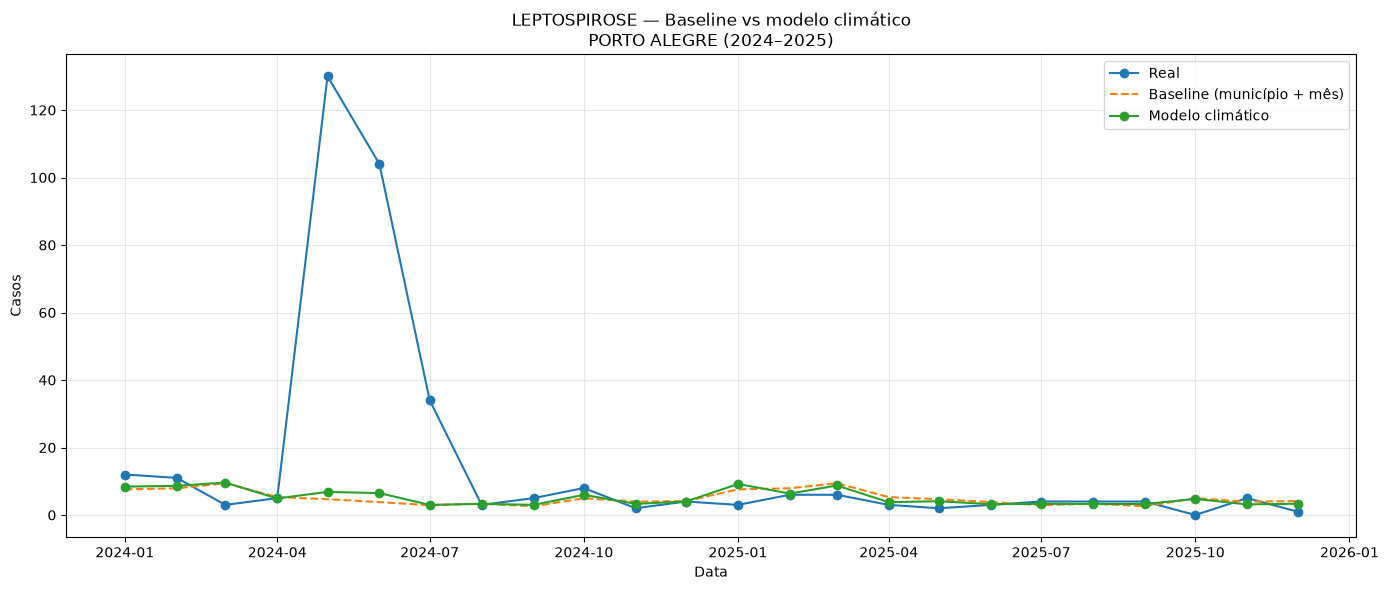

In [25]:
plot_df = resultado["test_final"][resultado["test_final"]["municipality"] == "PORTO ALEGRE"].copy()
plot_df["baseline_pred"] = base_model.predict(plot_df)
plot_df["climate_pred"] = final_model.predict(plot_df)

mu.plot_baseline_vs_climate(DISEASE, "PORTO ALEGRE", plot_df)

### D) Tabela de métricas por município

**Atenção**: MAE, RMSE e WAPE por município **não devem ser interpretados como "acurácia"**, especialmente em municípios com poucos casos ou meses de zero casos — comuns em leptospirose fora de Porto Alegre —, onde pequenos erros absolutos geram percentuais de erro elevados e pouco informativos.

In [26]:
evaluation_df = resultado["test_final"][["municipality", "reference_date", "cases"]].copy()
evaluation_df["prediction"] = resultado["final_pred"]

municipality_metrics = mu.municipality_metrics_table(evaluation_df)
display(municipality_metrics.round(4))

,municipality,n,mean_cases,mae,rmse,wape_pct,r2
0,SANTIAGO,12,0.0833,0.1916,0.2549,229.8764,0.1494
1,TORRES,3,0.0000,0.2434,0.2641,NaN,NaN
2,LAGOA VERMELHA,12,0.0833,0.1450,0.2768,173.9449,-0.0033
3,CRUZ ALTA,23,0.0870,0.2021,0.2836,232.4072,-0.0127
4,URUGUAIANA,21,0.0952,0.2115,0.2876,222.1059,0.0403
5,VACARIA,24,0.1250,0.1879,0.3346,150.2818,-0.0238
6,CANELA,21,0.1429,0.2380,0.3536,166.5704,-0.0212
7,FREDERICO WESTPHALEN,12,0.0833,0.3096,0.3766,371.5379,-0.8565
8,CAMAQUA,23,0.2609,0.4273,0.4680,163.8038,-0.1357
9,TRAMANDAI,20,0.1500,0.2012,0.4848,134.1118,-0.0332


## 12. Municípios excluídos do backtest

Municípios presentes no teste mas ausentes no treino válido do modelo final (pelo dropna conjunto das features finais) são excluídos do backtest e listados abaixo — nenhuma categoria é inventada.

In [27]:
required_cols_final = ["cases", "municipality", "month"] + features_selecionadas
train_check = train_disease0.dropna(subset=required_cols_final)
test_check = test_disease0.dropna(subset=required_cols_final)

excluded_municipalities = mu.unseen_municipalities(train_check, test_check)

print("Municípios excluídos do backtest final:", excluded_municipalities if excluded_municipalities else "nenhum")
print(
    "Motivo: não há casos de leptospirose registrados para esses municípios "
    "no período de treino (2015-2023), então o modelo (que usa C(municipality)) "
    "não pode gerar previsões para eles sem inventar uma categoria nova."
)

Municípios excluídos do backtest final: {'SOLEDADE'}
Motivo: não há casos de leptospirose registrados para esses municípios no período de treino (2015-2023), então o modelo (que usa C(municipality)) não pode gerar previsões para eles sem inventar uma categoria nova.


## 13. Abordagens alternativas (experimento)

Análise exploratória adicional, fora do pipeline oficial. Investiga se falta, no modelo oficial (Binomial Negativa, `C(municipality) + C(month)`, efeito climático pooled), um mecanismo explícito de zero-inflação ou de heterogeneidade de patamar (intercepto) entre municípios — comparando-o a um Zero-Inflated NB (inflação constante) e a um Poisson hierárquico com **apenas intercepto aleatório** por município (o efeito do clima permanece pooled em ambas as alternativas).

Usa o mesmo split final (treino 2015–2023, teste 2024–2025, Soledade excluída) e as mesmas duas features da seção 9 (`precipitation_sum_mm_lag1`, `relative_humidity_avg_pct_lag1`). O modelo salvo em `artifacts/modeling/leptospirose_metrics.json` só seria substituído se alguma alternativa fosse clara e consistentemente melhor — decidido pelos números a seguir, não presumido de antemão.

### Parte A — falta zero-inflação ou intercepto aleatório?

#### A.1 Zero-Inflated NB (ZINB, implementação manual)

Mantém o efeito do clima pooled; adiciona um mecanismo explícito de "zero estrutural" via um componente de inflação (intercepto constante), além do que os efeitos fixos de município já capturam.

In [28]:
import patsy
from statsmodels.discrete.count_model import ZeroInflatedNegativeBinomialP

train_final_alt = resultado["train_final"]
test_final_alt = resultado["test_final"]

zinb_formula = "cases ~ C(municipality) + C(month) + " + " + ".join(features_selecionadas)
y_zinb, X_zinb = patsy.dmatrices(zinb_formula, train_final_alt, return_type="dataframe")
y_zinb_test, X_zinb_test = patsy.build_design_matrices(
    [y_zinb.design_info, X_zinb.design_info], test_final_alt, return_type="dataframe"
)

zinb_model = ZeroInflatedNegativeBinomialP(
    y_zinb, X_zinb, exog_infl=np.ones((len(y_zinb), 1)), inflation="logit"
).fit(method="bfgs", maxiter=2000, disp=False)

pred_zinb = zinb_model.predict(X_zinb_test, exog_infl=np.ones((len(X_zinb_test), 1)))
zinb_metrics = mu.regression_metrics(test_final_alt["cases"], pred_zinb)
zinb_converged = bool(zinb_model.mle_retvals.get("converged", False))
inflate_const = float(zinb_model.params.get("inflate_const", np.nan))
inflate_prob = float(1 / (1 + np.exp(-inflate_const)))

print("ZINB convergiu:", zinb_converged)
print("Constante de inflação (logit):", round(inflate_const, 4))
print("Probabilidade de inflação implícita:", inflate_prob)
print("MAE:", round(zinb_metrics["mae"], 4))
print("RMSE:", round(zinb_metrics["rmse"], 4))
print("R²:", round(zinb_metrics["r2"], 4))
print()
print("Correlação entre previsões ZINB e NB oficial:", round(float(np.corrcoef(pred_zinb, resultado["final_pred"])[0, 1]), 8))

C:\Users\eduar\Desktop\Projeto-Python\epidemiological-intelligence\.venv\Lib\site-packages\statsmodels\base\model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '


ZINB convergiu: True
Constante de inflação (logit): -13.7492
Probabilidade de inflação implícita: 1.0685830674906416e-06
MAE: 1.1838
RMSE: 7.8231
R²: 0.1046

Correlação entre previsões ZINB e NB oficial: 0.99999999


Com inflação constante, o ZINB converge para uma constante fortemente negativa (logit ≈-13,7 → probabilidade de inflação ≈10⁻⁶), e suas previsões no teste são praticamente idênticas às da NB oficial (correlação >0,9999999). Consistente com o esperado: `C(municipality)` já absorve boa parte da heterogeneidade de zeros entre municípios, sobrando pouco para um componente de inflação explicar.

#### A.2 Poisson hierárquico — apenas intercepto aleatório por município

Também mantém o efeito do clima pooled; o que varia por município é apenas o intercepto, via efeito aleatório com shrinkage. Diferente de um modelo com inclinação aleatória, esta variante não testa se o efeito do clima muda entre municípios — só se falta heterogeneidade de patamar além da já capturada por `C(municipality)`.

In [29]:
from statsmodels.genmod.bayes_mixed_glm import PoissonBayesMixedGLM

fe_formula_raw = "cases ~ C(month) + " + " + ".join(features_selecionadas)
y_hier_raw, X_hier_raw = patsy.dmatrices(fe_formula_raw, train_final_alt, return_type="dataframe")
Z_hier_raw = patsy.dmatrix("0 + C(municipality)", train_final_alt, return_type="dataframe")
ident_raw = np.zeros(Z_hier_raw.shape[1], dtype=int)

hier_model_raw = PoissonBayesMixedGLM(y_hier_raw.values.ravel(), X_hier_raw.values, Z_hier_raw.values, ident_raw)
hier_result_raw = hier_model_raw.fit_vb()

print("Convergiu (features em escala bruta):", hier_result_raw.optim_retvals.success)
print("Mensagem do otimizador:", hier_result_raw.optim_retvals.message)

Convergiu (features em escala bruta): False
Mensagem do otimizador: NaN result encountered.


C:\Users\eduar\Desktop\Projeto-Python\epidemiological-intelligence\.venv\Lib\site-packages\statsmodels\genmod\bayes_mixed_glm.py:1169: RuntimeWarning: overflow encountered in exp
  return -np.exp(tm + np.sqrt(tv) * z)
C:\Users\eduar\Desktop\Projeto-Python\epidemiological-intelligence\.venv\Lib\site-packages\statsmodels\genmod\bayes_mixed_glm.py:1184: RuntimeWarning: overflow encountered in exp
  y = -np.exp(tm + np.sqrt(tv) * z)
C:\Users\eduar\Desktop\Projeto-Python\epidemiological-intelligence\.venv\Lib\site-packages\statsmodels\genmod\bayes_mixed_glm.py:651: RuntimeWarning: invalid value encountered in dot
  fep_mean_grad += w[0] * np.dot(u, self.exog)
C:\Users\eduar\Desktop\Projeto-Python\epidemiological-intelligence\.venv\Lib\site-packages\statsmodels\genmod\bayes_mixed_glm.py:653: RuntimeWarning: invalid value encountered in dot
  fep_sd_grad += w[0] * z * np.dot(r, self.exog**2 * fep_sd)
C:\Users\eduar\Desktop\Projeto-Python\epidemiological-intelligence\.venv\Lib\site-packages\st

O ajuste direto (features em escala bruta, com `precipitation_sum_mm_lag1` em centenas de mm) **não converge** — erro numérico (`NaN result`), provavelmente por overflow na aproximação variacional quando os regressores têm escalas muito diferentes. Limitação prática da rotina de VB do `statsmodels`, não do modelo em si; resolvida padronizando (z-score, média/desvio do treino) as duas variáveis climáticas contínuas antes do ajuste, com a mesma padronização aplicada ao prever no teste.

In [30]:
climate_means = train_final_alt[features_selecionadas].mean()
climate_stds = train_final_alt[features_selecionadas].std()

train_hier = train_final_alt.copy()
test_hier = test_final_alt.copy()

z_features = []
for col in features_selecionadas:
    z_col = f"{col}_z"
    train_hier[z_col] = (train_hier[col] - climate_means[col]) / climate_stds[col]
    test_hier[z_col] = (test_hier[col] - climate_means[col]) / climate_stds[col]
    z_features.append(z_col)

fe_formula_z = "cases ~ C(month) + " + " + ".join(z_features)
y_hier, X_hier = patsy.dmatrices(fe_formula_z, train_hier, return_type="dataframe")
Z_hier = patsy.dmatrix("0 + C(municipality)", train_hier, return_type="dataframe")
ident = np.zeros(Z_hier.shape[1], dtype=int)

hier_model = PoissonBayesMixedGLM(y_hier.values.ravel(), X_hier.values, Z_hier.values, ident)

hier_converged = False
for seed in range(10):
    np.random.seed(seed)
    hier_result = hier_model.fit_vb()
    if hier_result.optim_retvals.success:
        hier_converged = True
        break

print("Convergiu (features padronizadas):", hier_converged, "| seed usada:", seed)

y_hier_test, X_hier_test = patsy.build_design_matrices(
    [y_hier.design_info, X_hier.design_info], test_hier, return_type="dataframe"
)
Z_hier_test = patsy.build_design_matrices([Z_hier.design_info], test_hier, return_type="dataframe")[0]

lin_pred_hier = X_hier_test.values @ hier_result.fe_mean + Z_hier_test.values @ hier_result.vc_mean
pred_hier = np.exp(lin_pred_hier)

hier_metrics = mu.regression_metrics(test_hier["cases"], pred_hier)

print("MAE:", round(hier_metrics["mae"], 4))
print("RMSE:", round(hier_metrics["rmse"], 4))
print("R²:", round(hier_metrics["r2"], 4))

Convergiu (features padronizadas): True | seed usada: 0
MAE: 1.1785
RMSE: 7.7908
R²: 0.1119


#### Tabela comparativa — Parte A

In [31]:
comparison_table = pd.DataFrame([
    {
        "modelo": "Binomial Negativa (oficial, pooled)",
        "mae": resultado["final_metrics"]["mae"],
        "rmse": resultado["final_metrics"]["rmse"],
        "r2": resultado["final_metrics"]["r2"],
        "convergiu": resultado["final_converged"],
    },
    {
        "modelo": "ZINB (inflação constante, efeito do clima pooled)",
        "mae": zinb_metrics["mae"],
        "rmse": zinb_metrics["rmse"],
        "r2": zinb_metrics["r2"],
        "convergiu": zinb_converged,
    },
    {
        "modelo": "Poisson hierárquico (só intercepto aleatório; clima pooled)",
        "mae": hier_metrics["mae"],
        "rmse": hier_metrics["rmse"],
        "r2": hier_metrics["r2"],
        "convergiu": hier_converged,
    },
])

display(comparison_table.round(4))

,modelo,mae,rmse,r2,convergiu
0,"Binomial Negativa (oficial, pooled)",1.1838,7.8231,0.1046,True
1,"ZINB (inflação constante, efeito do clima pooled)",1.1838,7.8231,0.1046,True
2,Poisson hierárquico (só intercepto aleatório; ...,1.1785,7.7908,0.1119,True


### Leitura da Parte A

Nenhuma alternativa supera a NB oficial de forma clara. O **ZINB** é, na prática, indistinguível da NB (correlação >0,9999999): os efeitos fixos de município já capturam a heterogeneidade de zeros, sem sobrar variabilidade para um componente de inflação explicar. O **Poisson hierárquico** (só intercepto aleatório) tem vantagem numérica pequena (MAE/RMSE ≈0,4–0,5% menores, R² ≈0,007 maior), dentro da variação esperada de uma aproximação variacional em um único split — não é ganho suficiente para substituir o modelo oficial. Também não tem parâmetro de dispersão extra (`alpha`); essa ausência não penalizar muito o desempenho é consistente com o `alpha` da NB oficial ser moderado (≈0,23).

Conclusão: não há evidência clara de que falte zero-inflação ou heterogeneidade de patamar além do que `C(municipality)` já captura. A Binomial Negativa **permanece como modelo oficial**, usada no artefato `leptospirose_metrics.json` e na comparação entre doenças do notebook 09.

## 14. Interpretação final

O modelo de referência (Binomial Negativa, município + mês) já captura parte relevante da variação estrutural e da sazonalidade. Ainda assim, leptospirose é consideravelmente mais rara/esparsa que outras doenças do projeto (muitos municípios com zero casos, forte concentração em Porto Alegre), refletindo-se em métricas absolutas pequenas e maior dificuldade de ajuste fora de Porto Alegre.

As variáveis selecionadas — precipitação acumulada com lag de 1 mês e umidade relativa com lag de 1 mês — **contribuíram para a previsão** fora da amostra, reduzindo MAE e RMSE em relação ao modelo-base, com coeficientes positivos e estatisticamente significativos. Isso é consistente com a transmissão da leptospirose por contato com água/solo contaminados: mais chuva um mês antes e maior umidade relativa contemporânea estão **associadas** a mais casos — nunca lido como relação causal. O modelo final convergiu adequadamente, com `alpha` positivo e distante de zero, confirmando sobredispersão residual mesmo após controlar por município, mês e clima.

Em termos absolutos, porém, a capacidade preditiva permanece modesta: R² fora da amostra ≈0,10, ou seja, o modelo explica só uma pequena fração da variância dos casos mensais — esperado para uma doença rara/esparsa cujo período de teste inclui um evento extremo (enchentes do RS em 2024). O ganho percentual de MAE/RMSE deve ser lido como melhora relativa modesta, não como alta capacidade preditiva em termos absolutos.

Nem toda variável climática teve ganho relevante: temperatura, ponto de orvalho, pressão e vento tiveram ganho nulo, negativo ou inconsistente entre lags, mesmo quando estatisticamente significativos isoladamente (ex.: ponto de orvalho, p<0,0001, mas piora de MAE) — reforçando que significância estatística não implica capacidade preditiva, e vice-versa.

**Nota sobre as enchentes do Rio Grande do Sul em 2024**: o período de teste inclui o pico anômalo de casos em Porto Alegre em maio/junho de 2024, associado às enchentes que atingiram o estado. Os dados foram mantidos integralmente no conjunto de teste, sem remoção, ajuste ou qualquer forma de tratamento como outlier, e o modelo **não foi otimizado para detectar esse tipo de evento**. Fatores como exposição direta à água da enchente, condições de saneamento, deslocamento populacional e danos à infraestrutura urbana não estão representados no modelo. A capacidade do modelo de acompanhar esse pico específico (seção 11-C) deve ser lida como uma limitação a ser considerada, e não como um objetivo de detecção de surtos alcançado.

**Limitações gerais**: o modelo é uma associação estatística controlada por município e sazonalidade — não estabelece relação causal entre clima e número de casos de leptospirose. Os coeficientes climáticos devem ser lidos como "associado a" ou "contribuiu para a previsão", nunca como "causou" ou "provocou". A qualidade do ajuste varia fortemente entre municípios (seção 11-D), sendo consideravelmente menos confiável em municípios com poucos casos, séries curtas ou muitos meses de zero casos — e mais confiável em Porto Alegre, onde há volume suficiente de dados.

Um experimento exploratório adicional (seção 13) testou se falta, no modelo oficial, um mecanismo explícito de zero-inflação ou de intercepto aleatório por município, além dos efeitos fixos já usados. A resposta foi não: nem o ZINB nem o Poisson hierárquico com apenas intercepto aleatório superaram a NB oficial de forma clara. O modelo oficial usado nos artefatos permanece a Binomial Negativa com efeito do clima pooled.

## 15. Persistência de artefatos

Métricas (JSON) e previsões de teste (parquet) são salvas em `artifacts/modeling/` via `mu.save_disease_artifacts`.

In [32]:
metrics = {
    "disease": DISEASE,
    "disease_key": "leptospirose",
    "formula": resultado["formula"],
    "alpha": resultado["alpha"],
    "converged": resultado["final_converged"],
    "base_converged": resultado["base_converged"],
    "aic": final_model.aic,
    "log_likelihood": final_model.llf,
    "coefficients": final_model.params.to_dict(),
    "pvalues": final_model.pvalues.to_dict(),
    "baseline_mae": resultado["base_metrics"]["mae"],
    "baseline_rmse": resultado["base_metrics"]["rmse"],
    "model_mae": resultado["final_metrics"]["mae"],
    "model_rmse": resultado["final_metrics"]["rmse"],
    "mae_improvement_pct": resultado["mae_improvement_pct"],
    "rmse_improvement_pct": resultado["rmse_improvement_pct"],
    "r2_test": resultado["final_metrics"]["r2"],
    "wape_pct": resultado["final_metrics"]["wape_pct"],
    "train_n": len(resultado["train_final"]),
    "test_n": len(resultado["test_final"]),
    "selected_features": features_selecionadas,
    "climate_variable_tests": climate_comparison.to_dict(orient="records"),
    "lag_variable_tests": lag_comparison.to_dict(orient="records"),
    "excluded_municipalities": list(excluded_municipalities),
    "feature_selection_validation_period": "2023-01-01 a 2023-12-01 (train_disease_fs = 2015-2022)",
    "feature_selection_rationale": feature_selection_rationale,
    "alternative_models_experiment": {
        "description": (
            "Experimento exploratorio (secao 13) comparando a Binomial Negativa "
            "oficial com ZINB (Zero-Inflated NB) e um Poisson hierarquico com "
            "intercepto aleatorio por municipio, nas mesmas features finais e no "
            "mesmo split 2015-2023/2024-2025. Nao substitui o modelo oficial "
            "abaixo."
        ),
        "zinb": {
            "mae": zinb_metrics["mae"],
            "rmse": zinb_metrics["rmse"],
            "r2": zinb_metrics["r2"],
            "converged": zinb_converged,
            "inflation_logit_const": inflate_const,
            "note": (
                "Previsoes praticamente identicas a NB oficial (correlacao > "
                "0.9999999); a inflacao de zeros colapsa para quase zero porque "
                "C(municipality) ja absorve a heterogeneidade de zeros entre "
                "municipios."
            ),
        },
        "poisson_hierarchical": {
            "mae": hier_metrics["mae"],
            "rmse": hier_metrics["rmse"],
            "r2": hier_metrics["r2"],
            "converged": hier_converged,
            "note": (
                "Vantagem numerica pequena sobre a NB oficial (~0.4-0.5% em "
                "MAE/RMSE), nao clara/substancial o suficiente para substituir o "
                "modelo oficial; exige padronizacao das features climaticas "
                "continuas para convergir de forma estavel via fit_vb()."
            ),
        },
        "conclusion": (
            "Nenhuma alternativa superou a NB oficial de forma clara e "
            "consistente; a Binomial Negativa foi mantida como modelo principal."
        ),
    },
    "note_extreme_event_2024": (
        "O periodo de teste inclui um pico anomalo de casos em Porto Alegre "
        "em maio/junho de 2024, associado as enchentes no Rio Grande do Sul. "
        "Os dados foram mantidos sem tratamento especial (sem remocao de "
        "outlier, sem ajuste), e o modelo nao foi otimizado para detectar "
        "esse tipo de evento; trata-se de uma limitacao do modelo, discutida "
        "na interpretacao final."
    ),
}

predictions_df = resultado["test_final"][["municipality", "reference_date", "cases"]].copy()
predictions_df["prediction"] = resultado["final_pred"]

mu.save_disease_artifacts("leptospirose", metrics, predictions_df)

print("Artefatos salvos em artifacts/modeling/leptospirose_metrics.json e leptospirose_predictions.parquet")

Artefatos salvos em artifacts/modeling/leptospirose_metrics.json e leptospirose_predictions.parquet


In [33]:
metrics_path = mu.ARTIFACTS_DIR / "leptospirose_metrics.json"
predictions_path = mu.ARTIFACTS_DIR / "leptospirose_predictions.parquet"

print("Métricas existe:", metrics_path.exists())
print("Previsões existe:", predictions_path.exists())

Métricas existe: True
Previsões existe: True
